In [1]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path
import numpy as np
import matplotlib.gridspec as gridspec

In [2]:
with open("SL_L.pkl", "rb") as f:
    SL_L= pickle.load(f)

In [2]:
params = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 1.0]

In [3]:
all_test = []

In [9]:
with open(f"/Users/compneuro1/Documents/projects/continuous_learning/power_s/auto_CL_a0.3_c5.pkl", "rb") as f:
    test_new= pickle.load(f)

In [10]:
test_new.keys()

dict_keys(['train_losses', 'val_losses', 'confusion_matrices', 'val_accuracies', 'lyas', 'time', 'lya_train', 'records'])

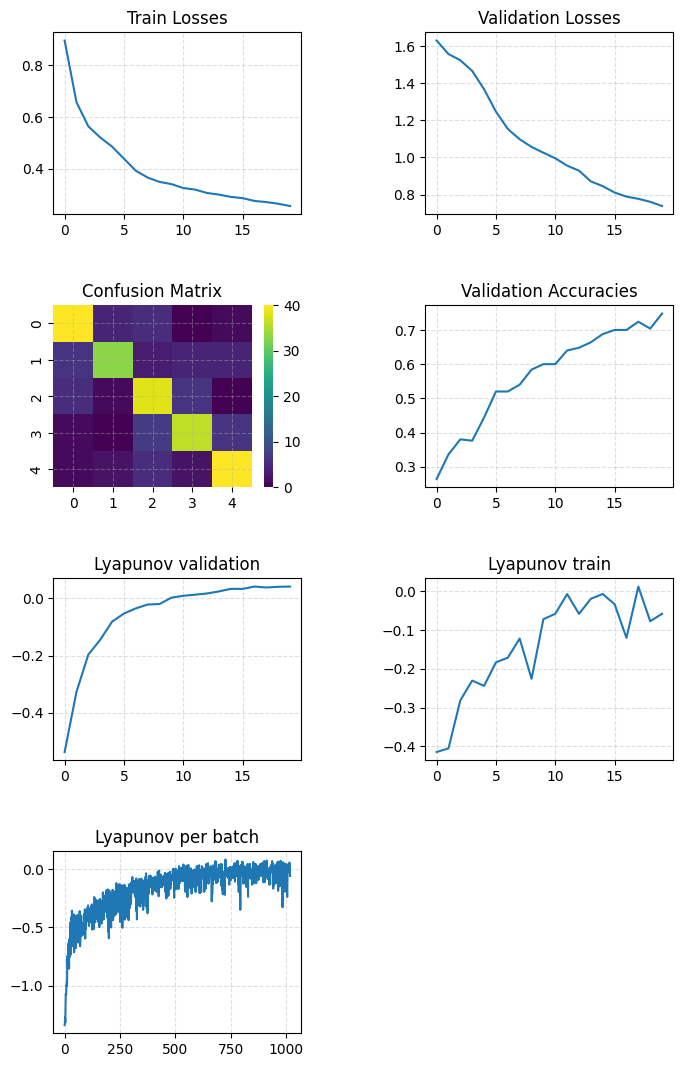

In [8]:
test = test_new

fig, axes = plt.subplots(4,2, figsize=(8,13))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(test["train_losses"])
axes[0,0].set_title("Train Losses")

axes[0,1].plot(test["val_losses"])
axes[0,1].set_title("Validation Losses")

sns.heatmap(test["confusion_matrices"][-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(test["val_accuracies"])
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(test["lyas"])
axes[2,0].set_title("Lyapunov validation")

axes[2,1].plot(test["lya_train"])
axes[2,1].set_title("Lyapunov train")

axes[3,0].plot(test["records"])
axes[3,0].set_title("Lyapunov per batch")


axes[3,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("c5_CL_5.png", dpi=300)

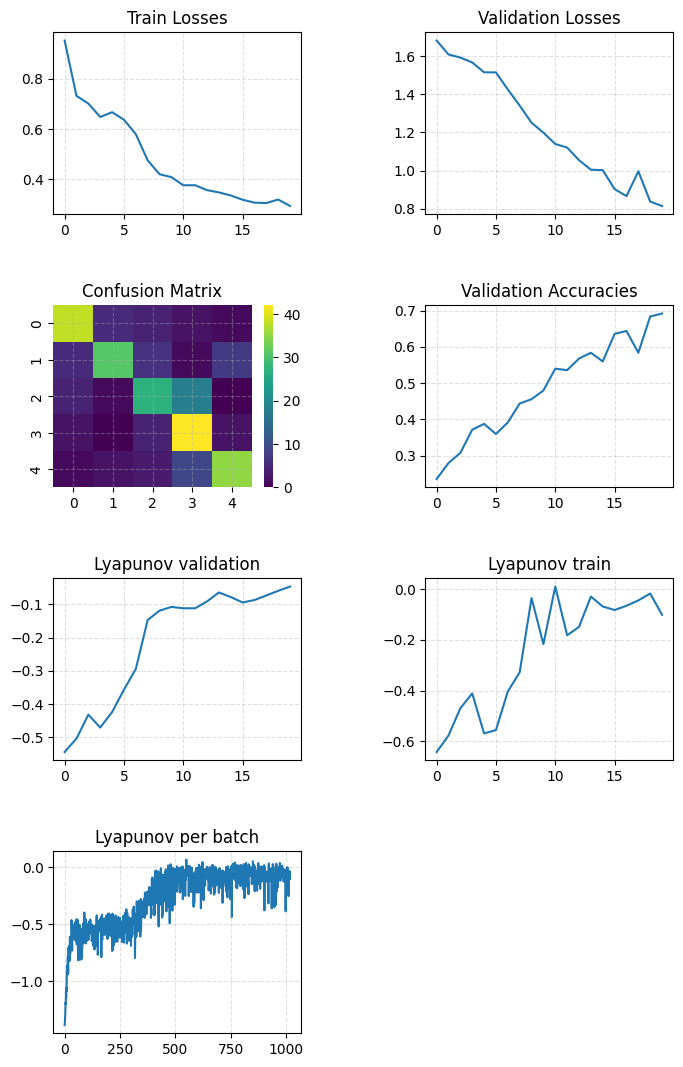

In [11]:
test = test_new

fig, axes = plt.subplots(4,2, figsize=(8,13))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(test["train_losses"])
axes[0,0].set_title("Train Losses")

axes[0,1].plot(test["val_losses"])
axes[0,1].set_title("Validation Losses")

sns.heatmap(test["confusion_matrices"][-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(test["val_accuracies"])
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(test["lyas"])
axes[2,0].set_title("Lyapunov validation")

axes[2,1].plot(test["lya_train"])
axes[2,1].set_title("Lyapunov train")

axes[3,0].plot(test["records"])
axes[3,0].set_title("Lyapunov per batch")


axes[3,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("c5_CL_5.png", dpi=300)

In [4]:
for i in params:
    with open(f"/Users/compneuro1/Documents/projects/continuous_learning/power_s/5c_resnet_400/auto_CL_a{i}_c5.pkl", "rb") as f:
        test_new= pickle.load(f)
        all_test.append(test_new)

In [29]:
all_test = []
for i in params:
    with open(f"/Users/compneuro1/Documents/projects/continuous_learning/power_s/5c_resnet_400/auto_CL_a{i}_c5.pkl", "rb") as f:
        test_new= pickle.load(f)
        all_test.append(test_new)
        
lya_list = []
val_list = []
for i in range(len(all_test)):
    val_list.append(all_test[i]["val_accuracies"])
    lya_list.append(all_test[i]["lya_train"])

lya_list = np.array(lya_list)
val_list = np.array(val_list)

# last_lya_list = lya_list[:,-60:]
# last_val_list = val_list[:,-60:]

In [20]:
lya_list_5 = lya_list
val_list_5 = val_list

In [21]:
all_lyas = np.stack([lya_list_0, lya_list_1, lya_list_2, lya_list_3, lya_list_4, lya_list_5])
all_vals = np.stack([val_list_0, val_list_1, val_list_2, val_list_3, val_list_4, val_list_5])

In [ ]:
all_lyas.shape

In [23]:
all_vals.shape

(6, 7, 200)

In [24]:
dict_all = {
    'all_lyas': all_lyas,
    'all_vals': all_vals
}

In [25]:
with open('/Users/compneuro1/Documents/projects/continuous_learning/power_s/5_repeats.pkl', 'wb') as f:
    pickle.dump(dict_all, f)

In [6]:
all_test[0].keys()

dict_keys(['train_losses', 'val_losses', 'confusion_matrices', 'val_accuracies', 'lyas', 'time', 'lya_train', 'records'])

In [ ]:
data = all_vals

fig, axes = plt.subplots(7, 1, figsize=(8, 14), sharex=True)
window = 10

for i in range(7):
    ax = axes[i]
    if i != 0:
        ax.set_ylim(0.85, 1)

    this_data = data[:, i, :]
    mean = this_data.mean(axis=0)
    smoothed = np.convolve(mean, np.ones(window)/window, mode="valid")
    std = this_data.std(axis=0) /np.sqrt(this_data.shape[0])
    x = np.arange(200)
    # ax.errorbar(np.arange(200), mean, yerr=std)
    ax.plot(np.arange(smoothed.shape[0]), smoothed)
    ax.fill_between(x, mean-std, mean+std, alpha=0.3)  
    ax.set_title(f"alpha {params[i]}")
    ax.grid(True)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy")

plt.legend()
plt.tight_layout()
plt.show()

/var/folders/v2/7v9psnv97b77q1l543tr9jbw0000gn/T/ipykernel_8079/2384969341.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


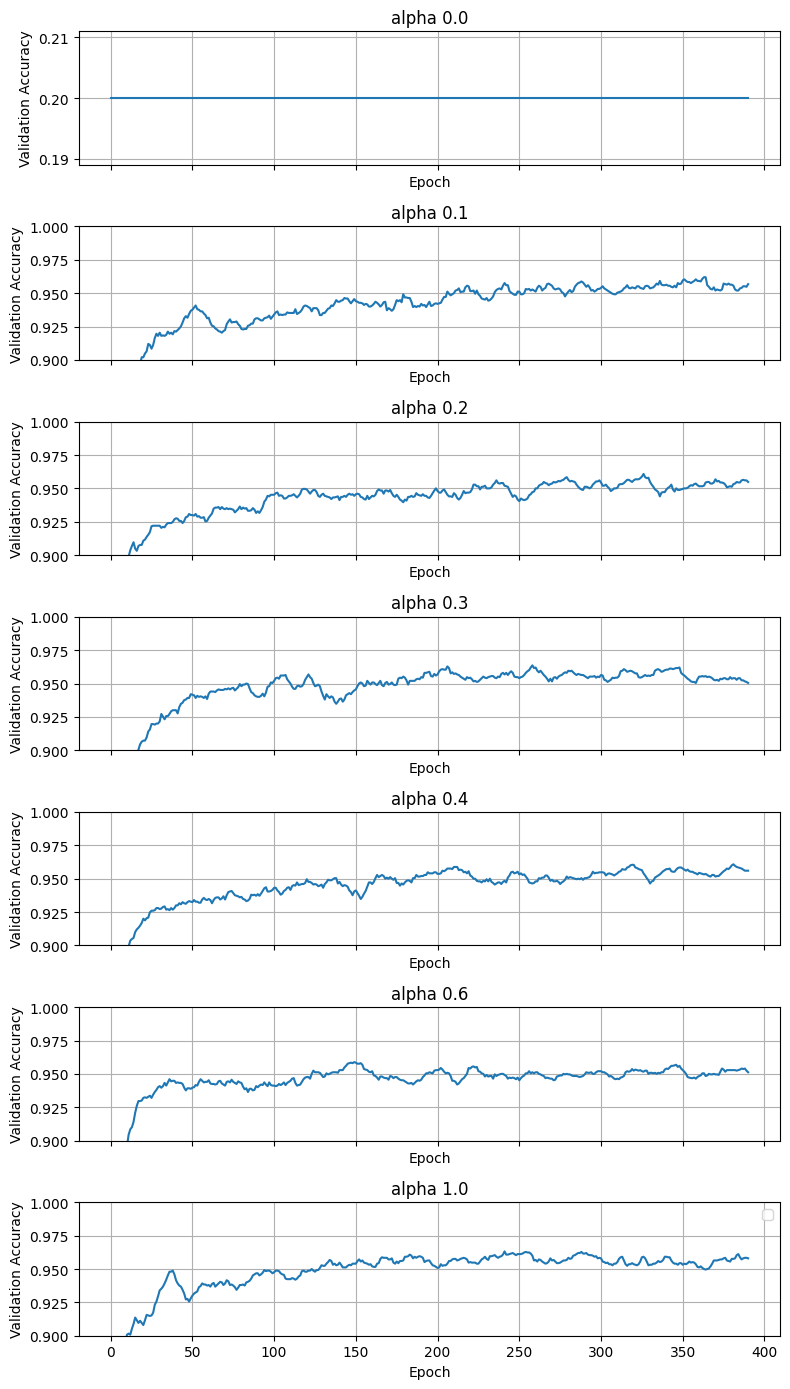

In [31]:
data = val_list

fig, axes = plt.subplots(7, 1, figsize=(8, 14), sharex=True)
window = 10

for i in range(val_list.shape[0]):
    ax = axes[i]
    if i != 0:
        # resnet
        ax.set_ylim(0.90, 1.0)

        # small network
        # ax.set_ylim(0.55, 0.95)

    # ax.set_ylim(-0.05, 0.05) 

    this_data = data[i, :]
    # mean = this_data.mean(axis=0)
    smoothed = np.convolve(this_data, np.ones(window)/window, mode="valid")
    # std = this_data.std(axis=0) /np.sqrt(this_data.shape[0])

    # ax.errorbar(np.arange(200), mean, yerr=std)
    ax.plot(np.arange(smoothed.shape[0]), smoothed)
    # ax.fill_between(x, mean-std, mean+std, alpha=0.3)  
    ax.set_title(f"alpha {params[i]}")
    ax.grid(True)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy")

plt.legend()
plt.tight_layout()
plt.savefig("val_power_400.png", dpi=300)
plt.show()

/var/folders/v2/7v9psnv97b77q1l543tr9jbw0000gn/T/ipykernel_8079/4182717162.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


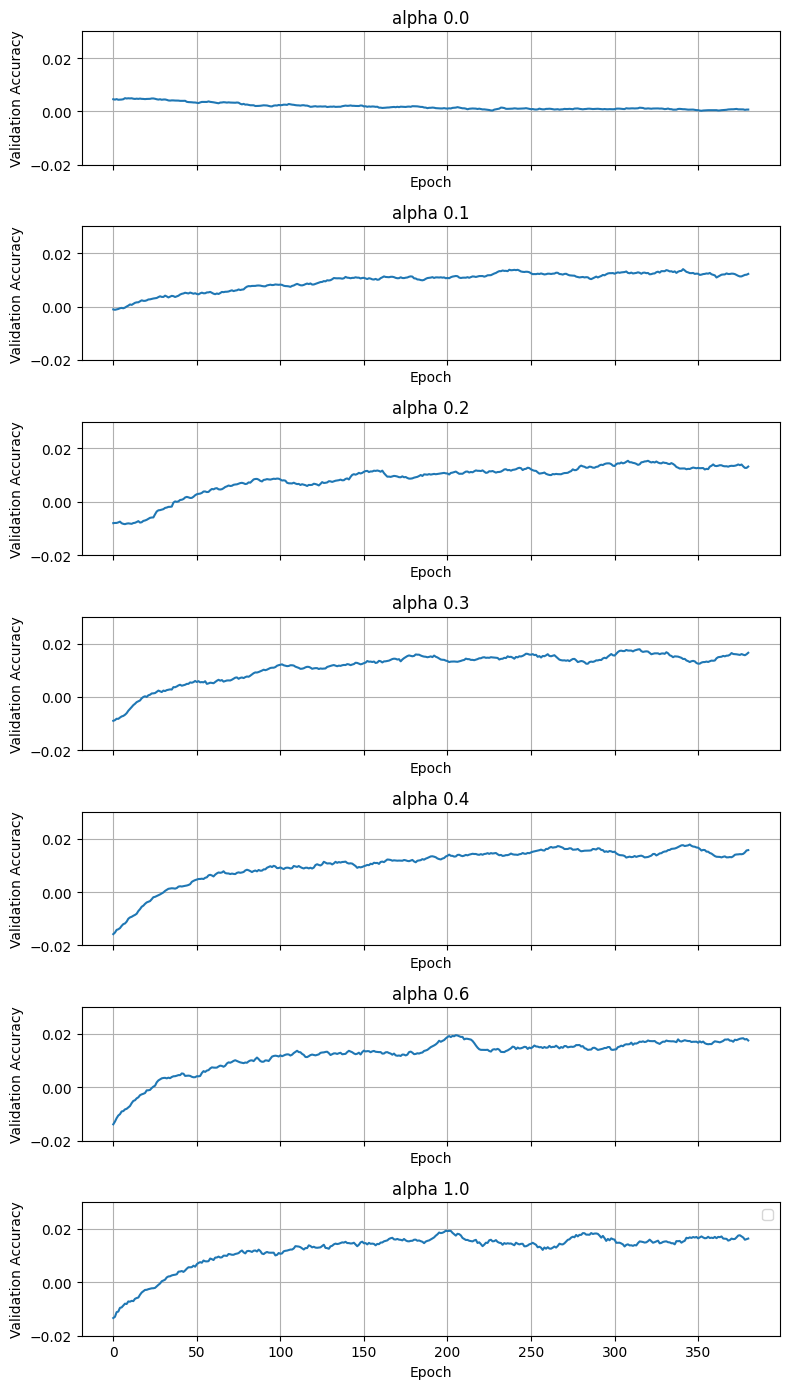

In [32]:
data = lya_list

fig, axes = plt.subplots(7, 1, figsize=(8, 14), sharex=True)
window = 20

for i in range(val_list.shape[0]):
    ax = axes[i]

    # resnet
    ax.set_ylim(-0.02, 0.03)

    # small network
    # ax.set_ylim(-0.4, 0.2)

    this_data = data[i, :]
    # mean = this_data.mean(axis=0)
    smoothed = np.convolve(this_data, np.ones(window)/window, mode="valid")
    # std = this_data.std(axis=0) /np.sqrt(this_data.shape[0])
    x = np.arange(200)
    # ax.errorbar(np.arange(200), mean, yerr=std)
    ax.plot(np.arange(smoothed.shape[0]), smoothed)
    # ax.fill_between(x, mean-std, mean+std, alpha=0.3)  
    ax.set_title(f"alpha {params[i]}")
    ax.grid(True)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy")

plt.legend()

plt.tight_layout()

plt.savefig("lya_power_400.png", dpi=300)
plt.show()

In [28]:
all_vals.shape

(6, 7, 200)

In [29]:
mean_vals = np.mean(all_vals, axis=0)

In [30]:
mean_vals.shape

(7, 200)

slide the window and see increase trend, need to smooth out first

In [77]:
after_window = []
window_size = 25
window = 10
for a in range(mean_vals.shape[0]):
    each_window = []
    alpha_vals = mean_vals[a]
    for w in range(alpha_vals.shape[0]):
        if w+window_size > alpha_vals.shape[0]:
            break
        else:
            temp = alpha_vals[w:w+window_size]
            this_window = np.convolve(temp, np.ones(window)/window, mode="valid")
            # get average 
            # each_window.append(np.mean(this_window))
            # difference
            each_window.append(this_window[-1] - this_window[0])
    after_window.append(each_window)

after_window = np.array(after_window)

In [78]:
after_window.shape

(7, 176)

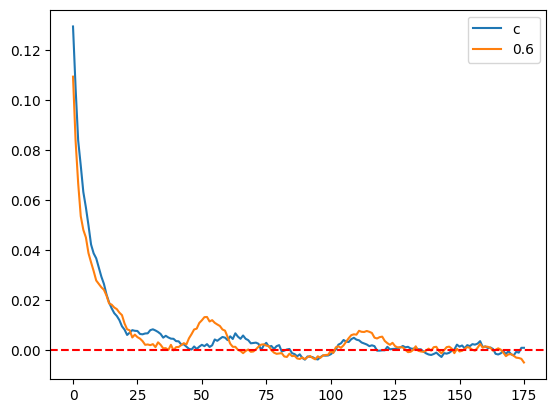

In [86]:
plt.plot(after_window[-1], label="c")
plt.plot(after_window[5], label=params[5])
plt.axhline(y=0, color='red', linestyle='--')
plt.legend()

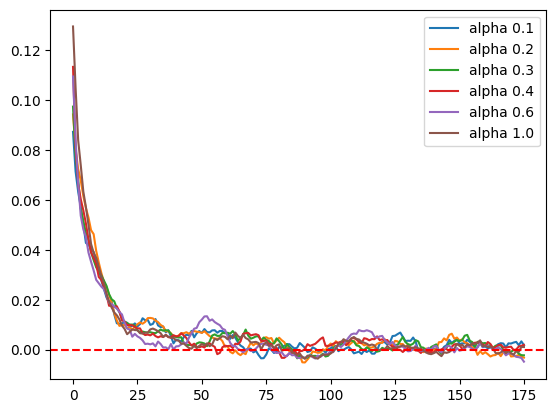

In [79]:
for i in range(after_window[1:].shape[0]):
    plt.plot(after_window[i+1], label=f"alpha {params[i+1]}")
plt.axhline(y=0, color='red', linestyle='--')
# plt.ylim([-0.05, 0.05])
plt.legend()

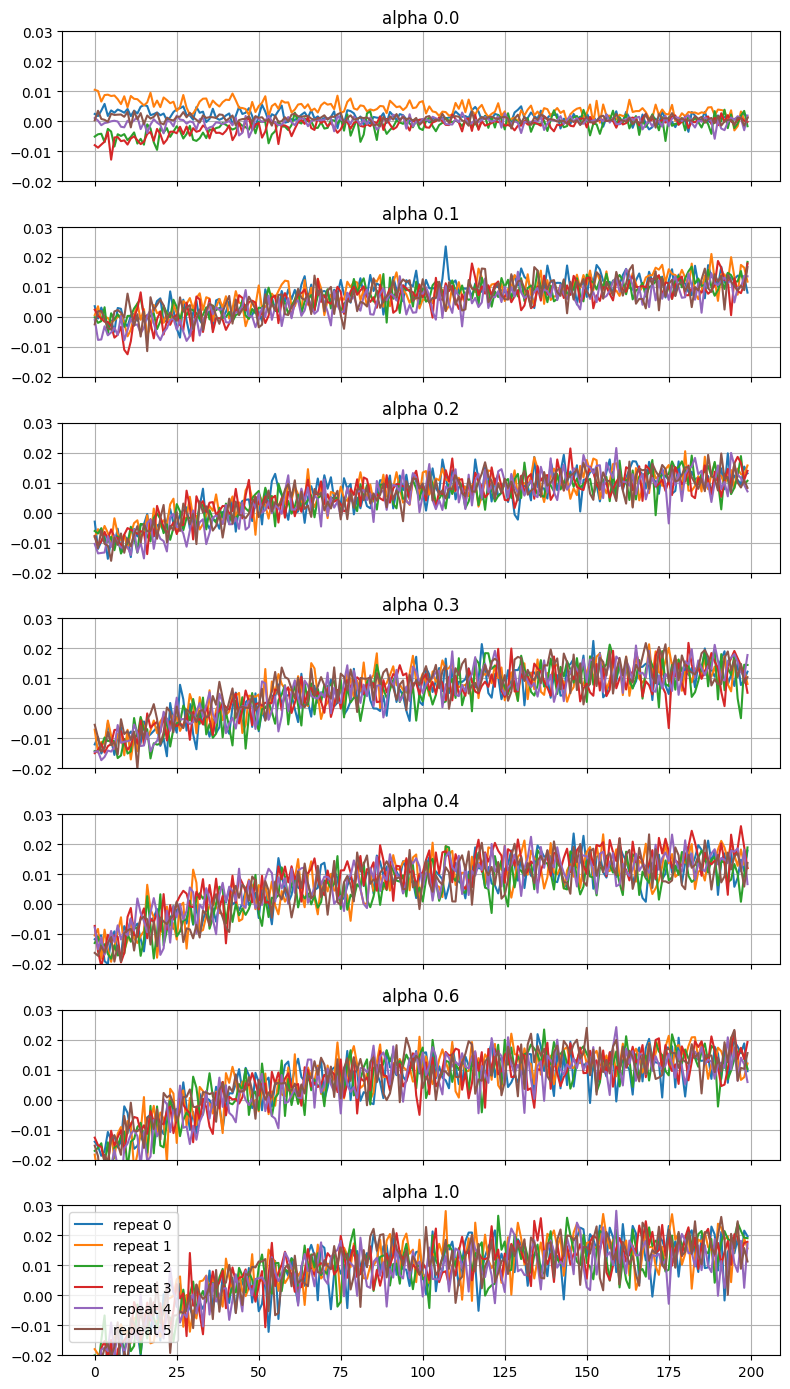

In [57]:
data = all_lyas

fig, axes = plt.subplots(7, 1, figsize=(8, 14), sharex=True)

for i in range(7):
    ax = axes[i]
    ax.set_ylim(-0.02, 0.03)
    for j in range(6):
        ax.plot(data[j, i, :], label=f"repeat {j}")  
    ax.set_title(f"alpha {params[i]}")
    ax.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

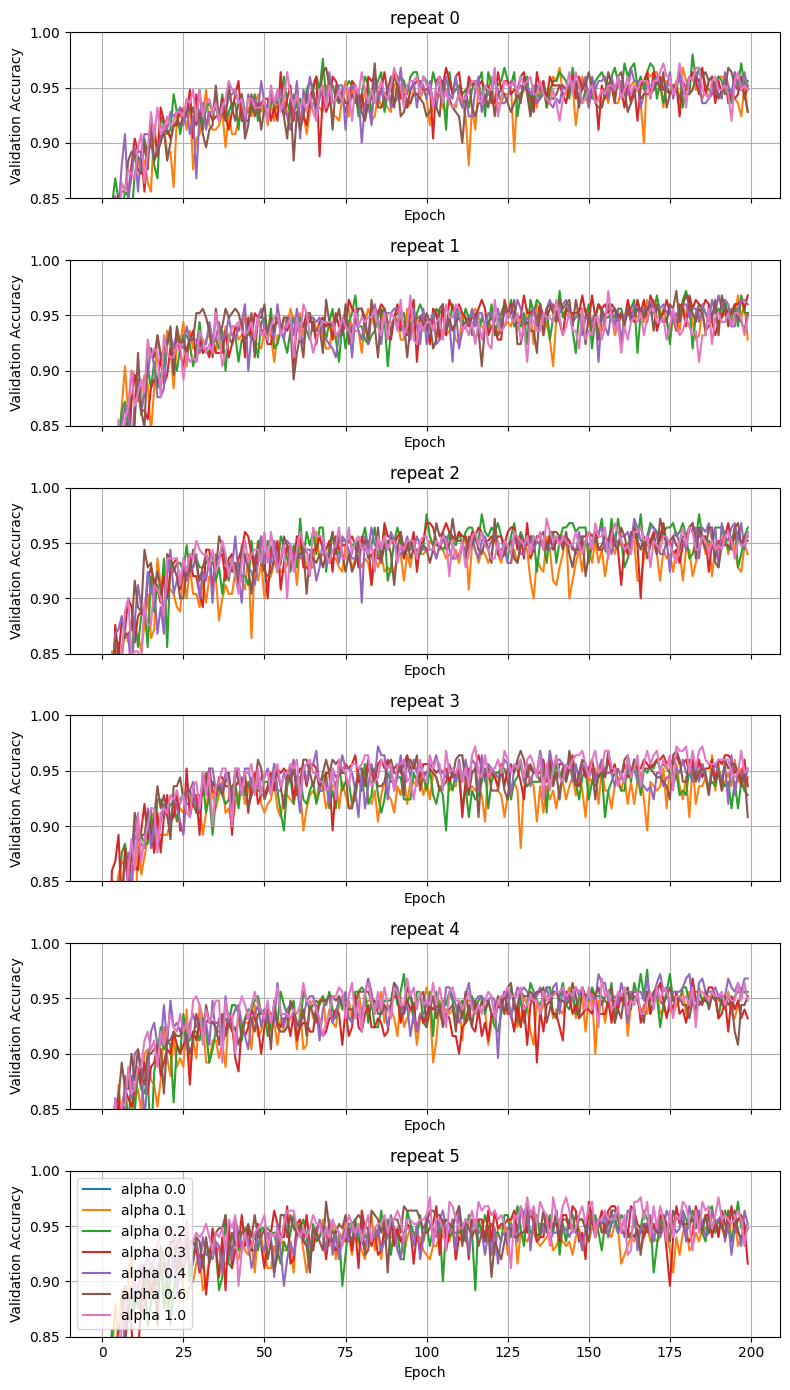

In [60]:
data = all_vals

fig, axes = plt.subplots(6, 1, figsize=(8, 14), sharex=True)

for i in range(6):
    ax = axes[i]

    ax.set_ylim(0.85, 1)
    for j in range(7):
        ax.plot(data[i, j, :], label=f"alpha {params[j]}")  
    ax.set_title(f"repeat {i}")
    ax.grid(True)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy")

plt.legend()

plt.tight_layout()
plt.show()

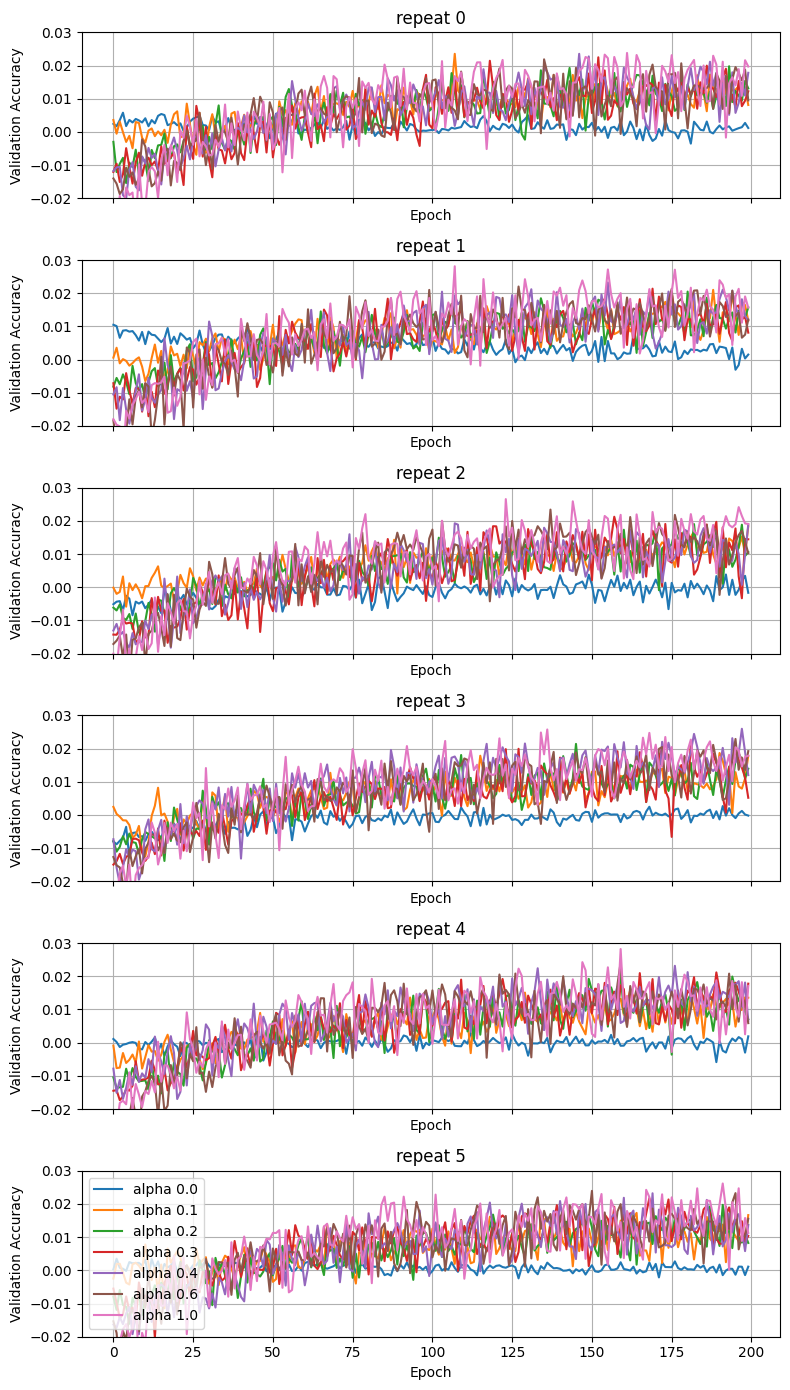

In [59]:
data = all_lyas

fig, axes = plt.subplots(6, 1, figsize=(8, 14), sharex=True)

for i in range(6):
    ax = axes[i]

    ax.set_ylim(-0.02, 0.03)
    for j in range(7):
        ax.plot(data[i, j, :], label=f"alpha {params[j]}")  
    ax.set_title(f"repeat {i}")
    ax.grid(True)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy")

plt.legend()

plt.tight_layout()
plt.show()

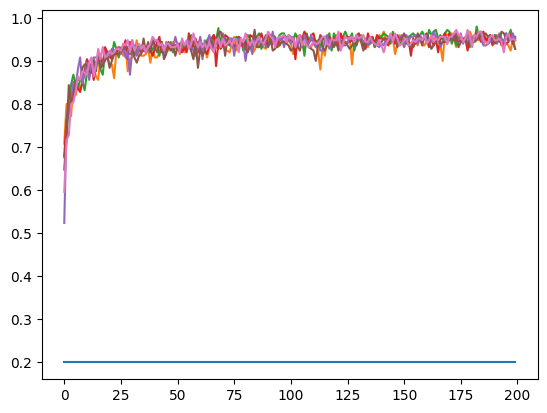

In [12]:

for i in range(val_list_0.shape[0]):
    plt.plot(val_list_0[i])

In [32]:
lya_0 = np.mean(last_lya_list, axis=1)
val_0 = np.mean(last_val_list, axis=1)

In [34]:
lya_1 = np.mean(last_lya_list, axis=1)
val_1 = np.mean(last_val_list, axis=1)

In [36]:
lya_2 = np.mean(last_lya_list, axis=1)
val_2 = np.mean(last_val_list, axis=1)

In [38]:
lya_3 = np.mean(last_lya_list, axis=1)
val_3 = np.mean(last_val_list, axis=1)

In [40]:
lya_4 = np.mean(last_lya_list, axis=1)
val_4 = np.mean(last_val_list, axis=1)

In [42]:
lya_5 = np.mean(last_lya_list, axis=1)
val_5 = np.mean(last_val_list, axis=1)

In [43]:
lya_stack = np.stack([lya_0, lya_1, lya_2, lya_3, lya_4, lya_5], axis=1)
val_stack = np.stack([val_0, val_1, val_2, val_3, val_4, val_5], axis=1)

# lya_stack = np.stack([lya_0, lya_1, lya_2], axis=1)
# val_stack = np.stack([val_0, val_1, val_2], axis=1)

In [32]:
def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5)
    ax.text((x1 + x2)/2, y + h, text, ha='center', va='bottom')

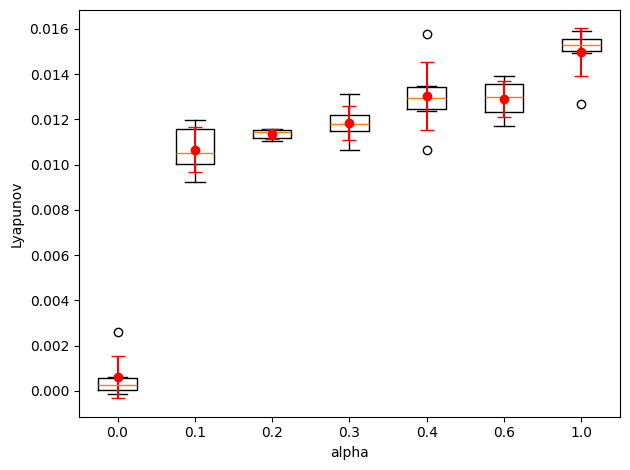

In [45]:
data = lya_stack

fig, ax = plt.subplots()
ax.boxplot(data.T)


means = np.mean(data, axis=1)
stds = np.std(data, axis=1)


x = np.arange(1, data.shape[0] + 1)


ax.errorbar(x, means, yerr=stds, fmt='o', color='red', capsize=5)

# Labels
ax.set_xticks(x)
ax.set_xticklabels([params[i] for i in range(data.shape[0])])
ax.set_xlabel('alpha')
ax.set_ylabel('Lyapunov')


# y = max(max(data[0]), max(data[-1]))  # height of bar
# h = 0.1 * y  # height of vertical ticks
# add_sig_bar(ax, 1, 7, y, h, '**')

# y = max(max(data[4]), max(data[-1]))  # height of bar
# h = 0.05 * y  # height of vertical ticks
# add_sig_bar(ax, 4, 7, y, h, '*')

plt.tight_layout()
# plt.savefig("lya_repeat.png", dpi=300)
plt.show()

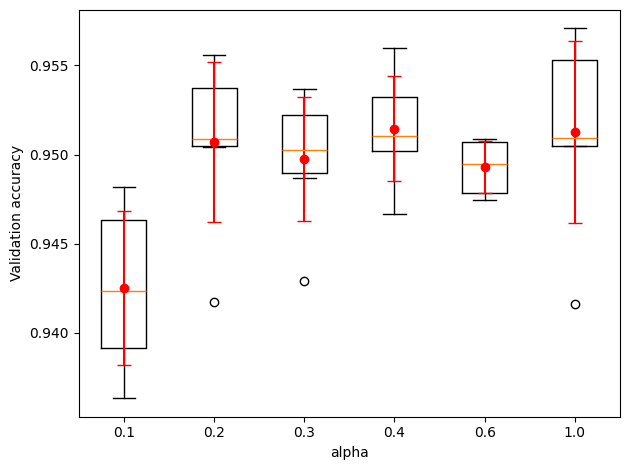

In [46]:
data = val_stack[1:]

fig, ax = plt.subplots()
ax.boxplot(data.T)


means = np.mean(data, axis=1)
stds = np.std(data, axis=1)


x = np.arange(1, data.shape[0] + 1)


ax.errorbar(x, means, yerr=stds, fmt='o', color='red', capsize=5)

# Labels
ax.set_xticks(x)
ax.set_xticklabels([params[i+1] for i in range(data.shape[0])])
ax.set_xlabel('alpha')
ax.set_ylabel('Validation accuracy')


# y = max(max(data[0]), max(data[-1]))  # height of bar
# h = 0.005 * y  # height of vertical ticks
# add_sig_bar(ax, 1, 6, y, h, '*')

plt.tight_layout()
# plt.savefig("acc_repeat.png", dpi=300)

plt.show()

In [8]:
all_test_0 = all_test

In [7]:
len(all_test)

7

/var/folders/v2/7v9psnv97b77q1l543tr9jbw0000gn/T/ipykernel_15143/1253389160.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


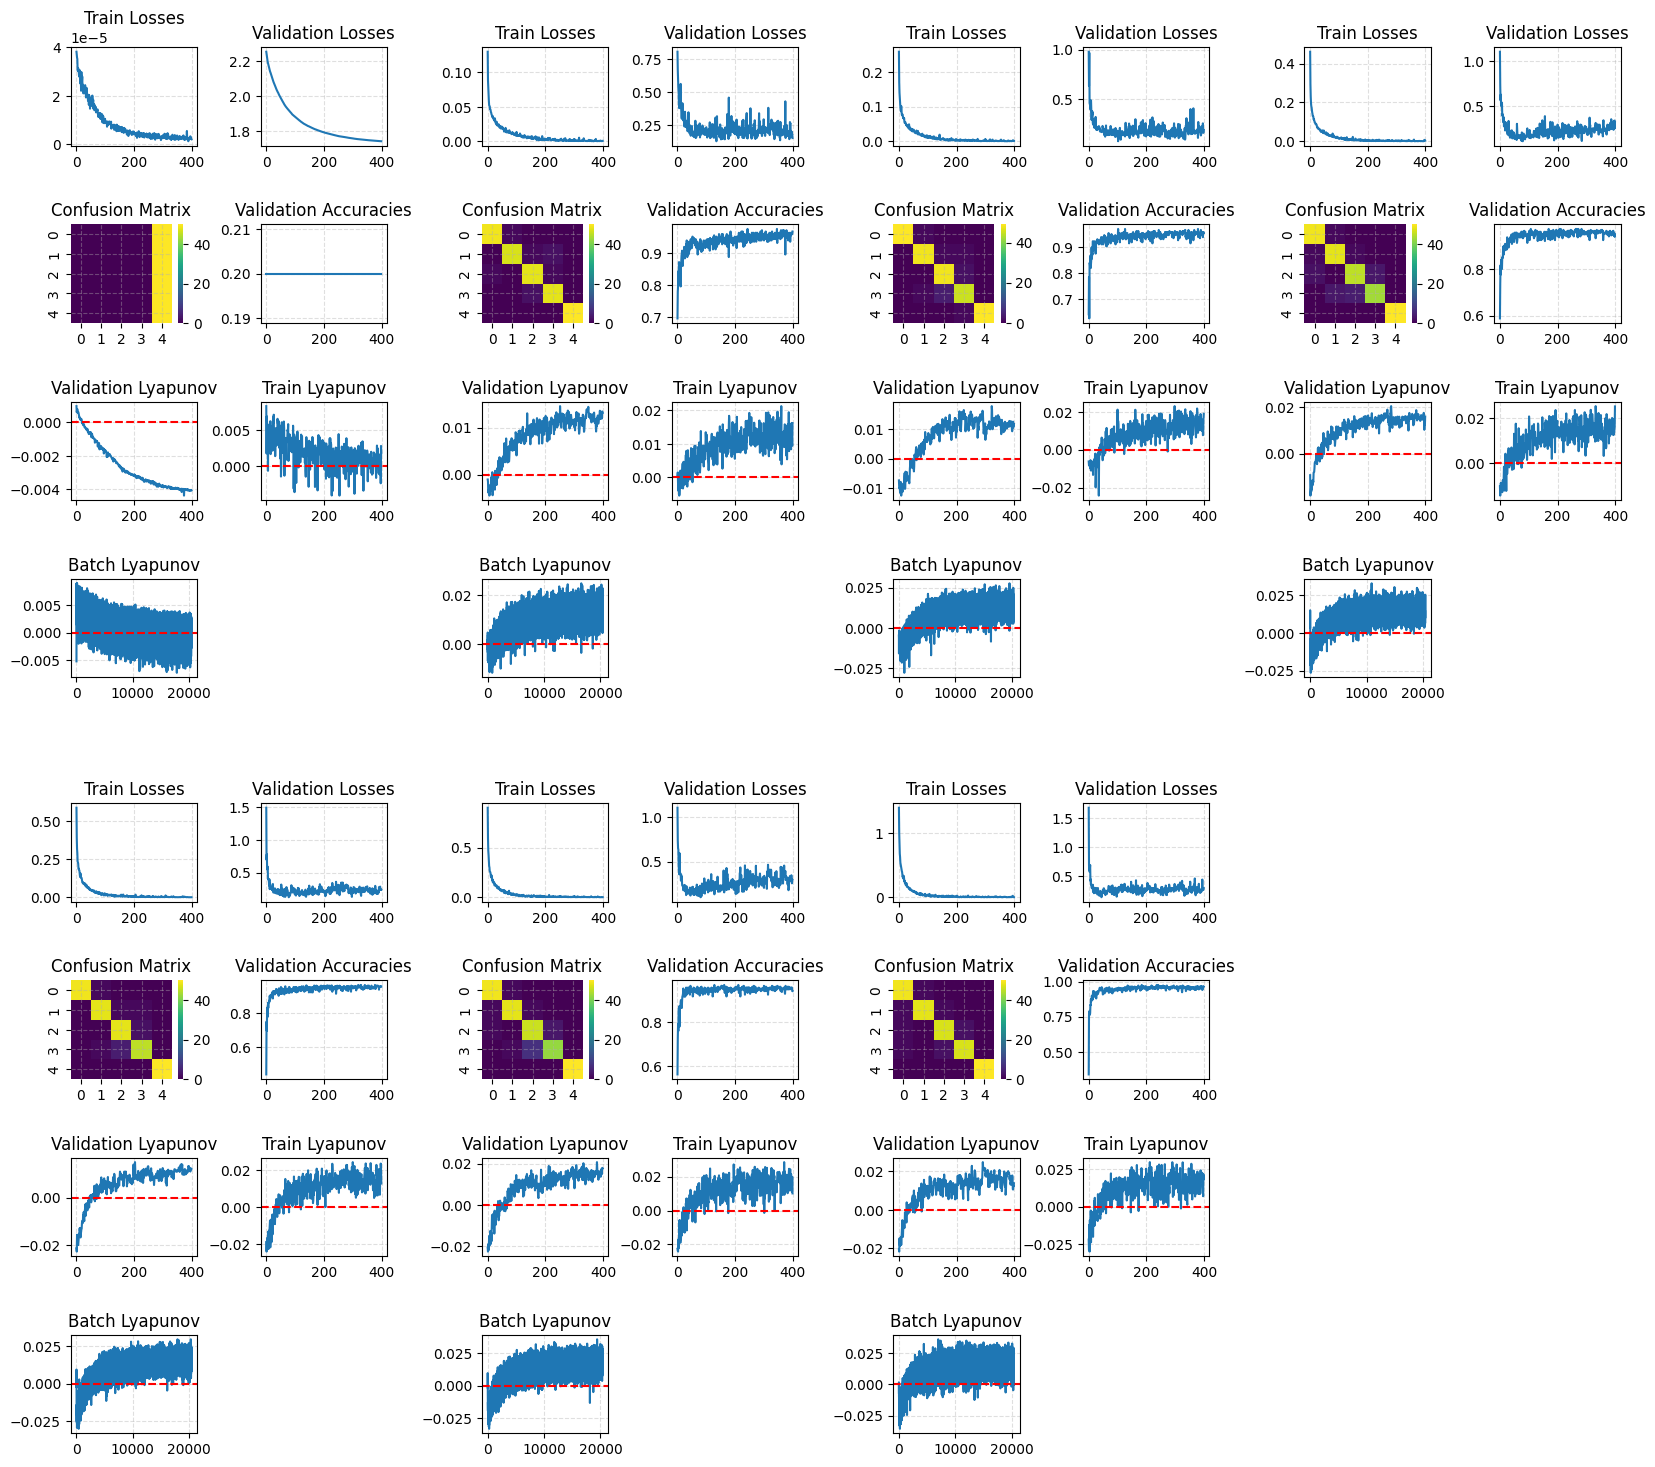

In [12]:
# plot loop
import math
n = 7

n_outer_rows = 2
n_outer_cols = math.ceil(n / n_outer_rows)

dataset = all_test


fig = plt.figure(figsize=(5 * n_outer_cols, 9 * n_outer_rows))
outer = gridspec.GridSpec(n_outer_rows, n_outer_cols, wspace=0.3, hspace=0.2)

for i in range(len(all_test)):
    r = i // n_outer_cols
    c = i % n_outer_cols

    inner = gridspec.GridSpecFromSubplotSpec(
        4, 2,
        subplot_spec=outer[r, c],
        wspace=0.5,
        hspace=0.8
    )

    axes = [fig.add_subplot(inner[r_, c_]) for r_ in range(4) for c_ in range(2)]
    axes = [axes[j:j+2] for j in range(0, len(axes), 2)]
    
    axes[0][0].plot(dataset[i]["train_losses"])
    axes[0][0].set_title("Train Losses")

    axes[0][1].plot(dataset[i]["val_losses"])
    axes[0][1].set_title("Validation Losses")

    sns.heatmap(dataset[i]["confusion_matrices"][-1], ax=axes[1][0], cmap="viridis")
    axes[1][0].set_title("Confusion Matrix")

    axes[1][1].plot(dataset[i]["val_accuracies"])
    axes[1][1].set_title("Validation Accuracies")

    axes[2][0].plot(dataset[i]["lyas"])
    axes[2][0].axhline(y=0, linestyle='--', color='red')
    axes[2][0].set_title("Validation Lyapunov")

    axes[2][1].plot(dataset[i]["lya_train"])
    axes[2][1].axhline(y=0, linestyle='--', color='red')
    axes[2][1].set_title("Train Lyapunov")

    axes[3][0].plot(dataset[i]["records"])
    axes[3][0].axhline(y=0, linestyle='--', color='red')
    axes[3][0].set_title("Batch Lyapunov")

    axes[3][1].axis("off")

    for row_axes in axes:
        for ax in row_axes:
            ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
# fig.savefig("5c_all.png", dpi=300)

In [6]:
len(all_test)

6

In [8]:
lya_list = []
val_list = []
for i in range(len(all_test)):
    val_list.append(all_test[i]["val_accuracies"])
    lya_list.append(all_test[i]["lya_train"])

In [9]:
lya_list = np.array(lya_list)
val_list = np.array(val_list)

In [10]:
last_lya_list = lya_list[:,-10:]
last_val_list = val_list[:,-10:]

In [11]:
last_val_list.shape

(7, 10)

In [78]:
lya_stack.shape

(7, 6)

In [106]:
from scipy.stats import mannwhitneyu

data = lya_stack
for i in range(data.shape[0]-1):
    stat, p = mannwhitneyu(data[i], data[-1], alternative="two-sided")
    print(f"Compare alpha {params[i]}")
    print("U statistics", stat)
    print("P value", p)
    print("----------")

Compare alpha 0.0
U statistics 0.0
P value 0.1
----------
Compare alpha 0.1
U statistics 0.0
P value 0.1
----------
Compare alpha 0.2
U statistics 0.0
P value 0.1
----------
Compare alpha 0.3
U statistics 0.0
P value 0.1
----------
Compare alpha 0.4
U statistics 1.0
P value 0.2
----------
Compare alpha 0.6
U statistics 0.0
P value 0.1
----------


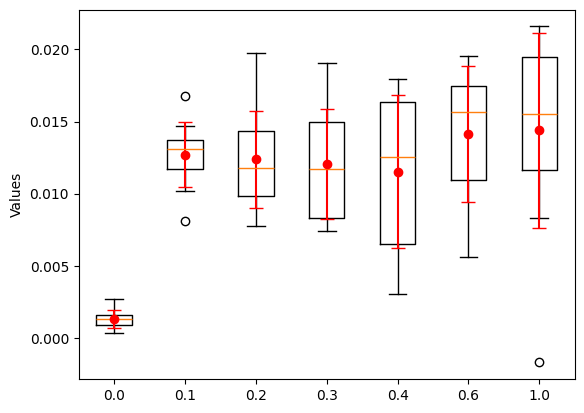

In [13]:
data = last_lya_list[:]

fig, ax = plt.subplots()
ax.boxplot(data.T)


means = np.mean(data, axis=1)
stds = np.std(data, axis=1)


x = np.arange(1, data.shape[0] + 1)


ax.errorbar(x, means, yerr=stds, fmt='o', color='red', capsize=5)

# Labels
ax.set_xticks(x)
ax.set_xticklabels([params[i] for i in range(data.shape[0])])
ax.set_ylabel('Values')

plt.show()

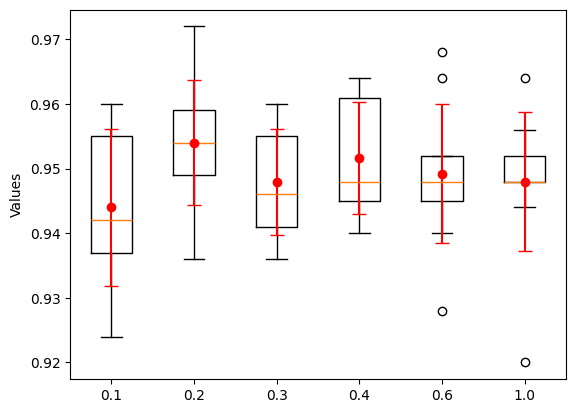

In [16]:
data = last_val_list[1:]

fig, ax = plt.subplots()
ax.boxplot(data.T)


means = np.mean(data, axis=1)
stds = np.std(data, axis=1)


x = np.arange(1, data.shape[0] + 1)


ax.errorbar(x, means, yerr=stds, fmt='o', color='red', capsize=5)

# Labels
ax.set_xticks(x)
ax.set_xticklabels([params[i+1] for i in range(data.shape[0])])
ax.set_ylabel('Values')

plt.show()

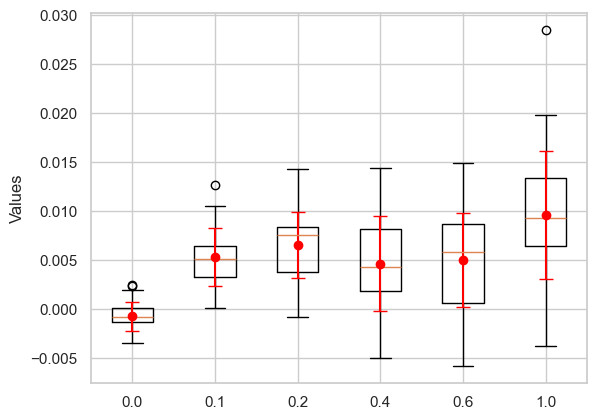

In [37]:
data = last_lya_list[:]

fig, ax = plt.subplots()
ax.boxplot(data.T)


means = np.mean(data, axis=1)
stds = np.std(data, axis=1)


x = np.arange(1, data.shape[0] + 1)


ax.errorbar(x, means, yerr=stds, fmt='o', color='red', capsize=5)

# Labels
ax.set_xticks(x)
ax.set_xticklabels([params[i] for i in range(data.shape[0])])
ax.set_ylabel('Values')

plt.show()

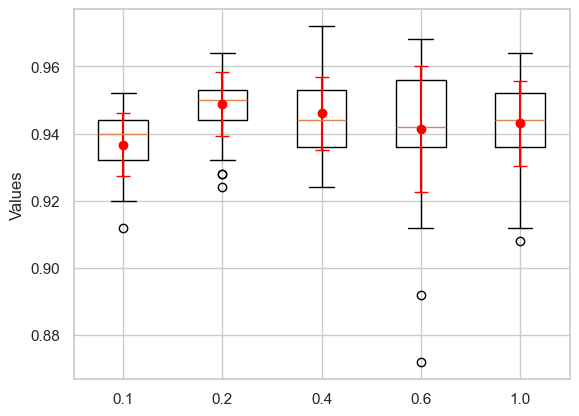

In [39]:
data = last_val_list[1:]

fig, ax = plt.subplots()
ax.boxplot(data.T)


means = np.mean(data, axis=1)
stds = np.std(data, axis=1)


x = np.arange(1, data.shape[0] + 1)


ax.errorbar(x, means, yerr=stds, fmt='o', color='red', capsize=5)

# Labels
ax.set_xticks(x)
ax.set_xticklabels([params[i+1] for i in range(data.shape[0])])
ax.set_ylabel('Values')

plt.show()

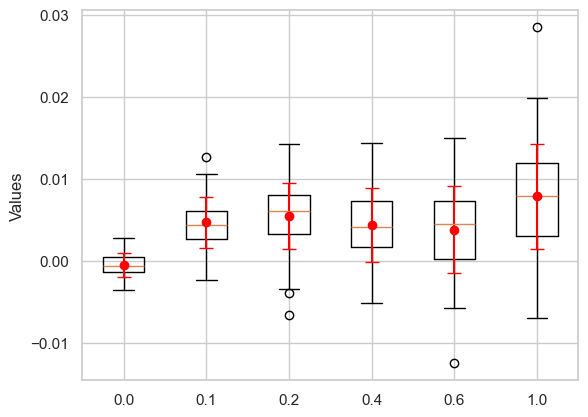

In [41]:
data = last_lya_list[:]

fig, ax = plt.subplots()
ax.boxplot(data.T)


means = np.mean(data, axis=1)
stds = np.std(data, axis=1)


x = np.arange(1, data.shape[0] + 1)


ax.errorbar(x, means, yerr=stds, fmt='o', color='red', capsize=5)

# Labels
ax.set_xticks(x)
ax.set_xticklabels([params[i] for i in range(data.shape[0])])
ax.set_ylabel('Values')

plt.show()

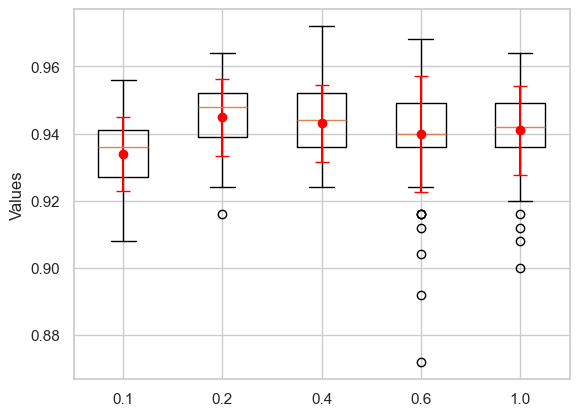

In [43]:
data = last_val_list[1:]

fig, ax = plt.subplots()
ax.boxplot(data.T)


means = np.mean(data, axis=1)
stds = np.std(data, axis=1)


x = np.arange(1, data.shape[0] + 1)


ax.errorbar(x, means, yerr=stds, fmt='o', color='red', capsize=5)

# Labels
ax.set_xticks(x)
ax.set_xticklabels([params[i+1] for i in range(data.shape[0])])
ax.set_ylabel('Values')

plt.show()

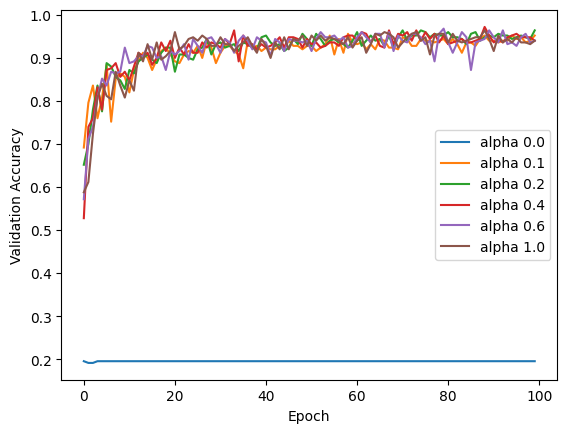

In [17]:
for i in range(6):
    # if i == 0:
    #     pass
    # else:
        plt.plot(val_list[i], label=f"alpha {params[i]}")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.savefig("acc_5c_all.png", dpi=300)

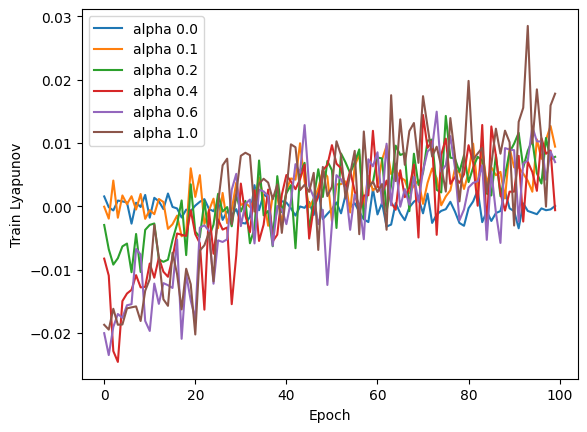

In [18]:
for i in range(len(all_test)):
    plt.plot(lya_list[i], label=f"alpha {params[i]}")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Train Lyapunov")
plt.savefig("5c_lya.png", dpi=300)

In [ ]:
SL_L

In [3]:
test_new.keys()

dict_keys(['train_losses', 'val_losses', 'confusion_matrices', 'val_accuracies', 'lyas', 'time', 'lya_train', 'records'])

In [8]:
test_new["val_accuracies"]

[0.15000000596046448,
 0.25279998779296875,
 0.3467999994754791,
 0.38839998841285706,
 0.4424000084400177,
 0.4684000015258789,
 0.49559998512268066,
 0.5216000080108643,
 0.525600016117096,
 0.5631999969482422,
 0.5425999760627747,
 0.5753999948501587,
 0.5784000158309937,
 0.5916000008583069,
 0.6001999974250793,
 0.6043999791145325,
 0.6057999730110168,
 0.6086000204086304,
 0.6014000177383423,
 0.6187999844551086]

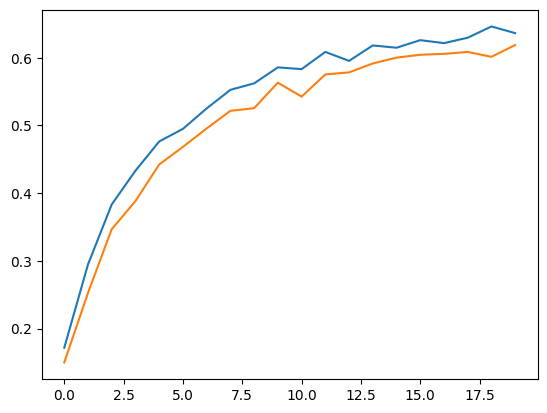

In [7]:
another_acc = [0.17180000245571136, 0.2948000133037567, 0.38339999318122864, 0.43320000171661377, 0.4763999879360199, 0.4950000047683716, 0.5252000093460083, 0.5526000261306763, 0.5622000098228455, 0.5857999920845032, 0.5831999778747559, 0.6086000204086304, 0.5953999757766724, 0.6182000041007996, 0.614799976348877, 0.6259999871253967, 0.6215999722480774, 0.6295999884605408, 0.6462000012397766, 0.6363999843597412]
plt.plot(another_acc)
plt.plot(test_new["val_accuracies"])

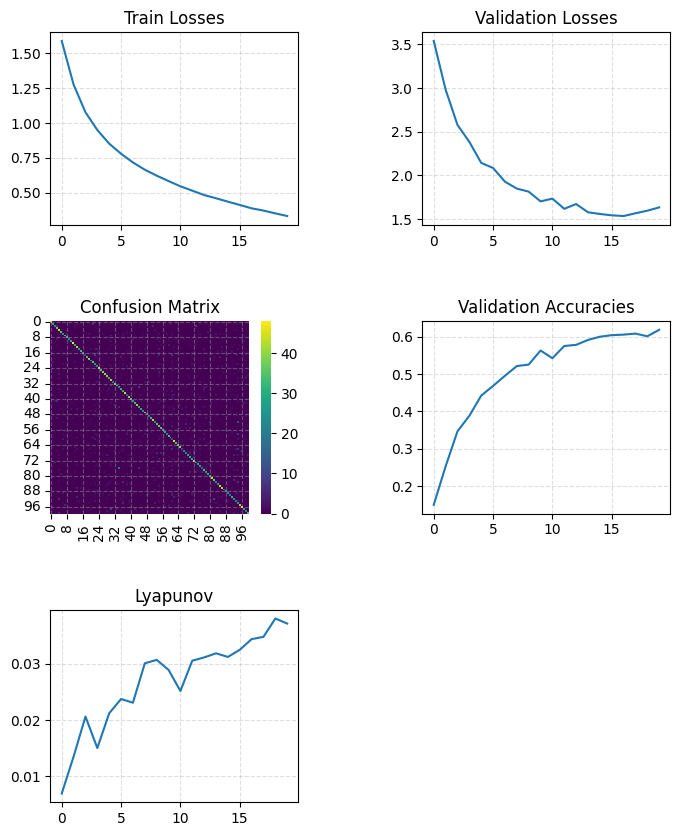

In [4]:
test = test_new

fig, axes = plt.subplots(3,2, figsize=(8,10))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes[0,0].plot(test["train_losses"])
axes[0,0].set_title("Train Losses")

axes[0,1].plot(test["val_losses"])
axes[0,1].set_title("Validation Losses")

sns.heatmap(test["confusion_matrices"][-1], ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Confusion Matrix")

axes[1,1].plot(test["val_accuracies"])
axes[1,1].set_title("Validation Accuracies")

axes[2,0].plot(test["lyas"])
axes[2,0].set_title("Lyapunov")

axes[2,1].axis("off")

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4)

# plt.savefig("c5_CL_5.png", dpi=300)

In [5]:
def average(lst):
    last_10 = lst[-5:]
    return sum(last_10)/len(last_10)

In [45]:
def load(set_alpha):
    all_data = {}

    folder = Path("/Users/compneuro1/Documents/projects/continuous_learning/power/downloads")

    for file in folder.glob(f"auto_CL_a{set_alpha}_c*.pkl"):
        with open(file, "rb") as f:
            all_data[file.stem] = pickle.load(f)

    sorted_keys = sorted(all_data.keys(), key=lambda x: int(x.split('_c')[-1]))

    val_accuracies = []
    for i in sorted_keys:
        val_accuracies.append(average(all_data[i]["val_accuracies"]))
    
    return val_accuracies

In [46]:
CL_val_accuracies_0 = load(0.0)
CL_val_accuracies_01 = load(0.01)
CL_val_accuracies_001 = load(0.001)
CL_val_accuracies_2 = load(0.2)
CL_val_accuracies_4 = load(0.4)
CL_val_accuracies_6 = load(0.6)
CL_val_accuracies_10 = load(1.0)

In [15]:
len(CL_val_accuracies_001)

5

In [43]:
mean = SL_L["SL_mean"]
std = SL_L["SL_std"]
L_val_accuracies = SL_L["L_val_accuracies"]

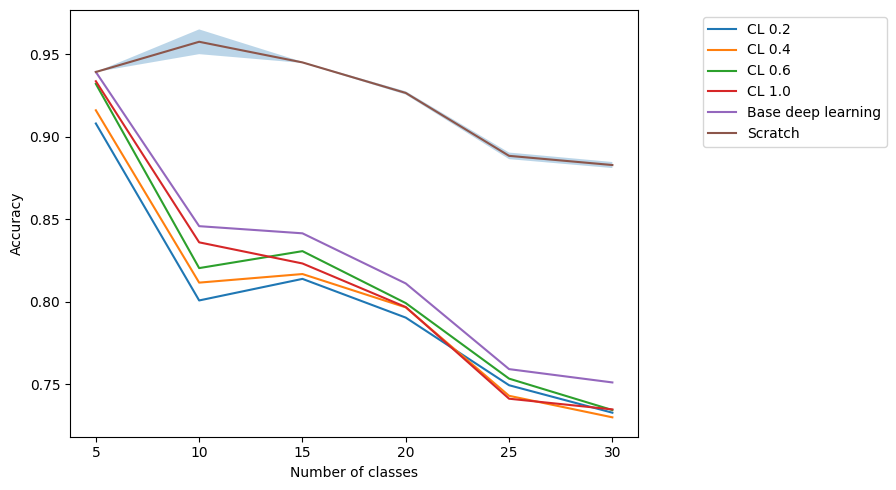

In [48]:
# x1= [5,10,15,20,25]
x= [5,10,15,20,25,30]

plt.figure(figsize=(10,5))

# plt.plot(x, CL_val_accuracies_0, label="CL 0.0")
# plt.plot(x, CL_val_accuracies_01, label="CL 0.01")
# plt.plot(x, CL_val_accuracies_001, label="CL 0.001")
plt.plot(x, CL_val_accuracies_2, label="CL 0.2")
plt.plot(x, CL_val_accuracies_4, label="CL 0.4")
plt.plot(x, CL_val_accuracies_6, label="CL 0.6")
plt.plot(x, CL_val_accuracies_10, label="CL 1.0")


plt.plot(x, L_val_accuracies, label="Base deep learning")

# plot scratch
plt.plot(x, mean, label="Scratch")
plt.fill_between(x, mean - std, mean + std, alpha=0.3)

plt.xlabel("Number of classes")
plt.ylabel("Accuracy")
plt.xticks([5,10,15,20,25,30])
plt.legend(loc="upper right", bbox_to_anchor=(1.45,1))
plt.tight_layout()
plt.savefig("compare_power_sub.png", dpi=300)